In [21]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [22]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

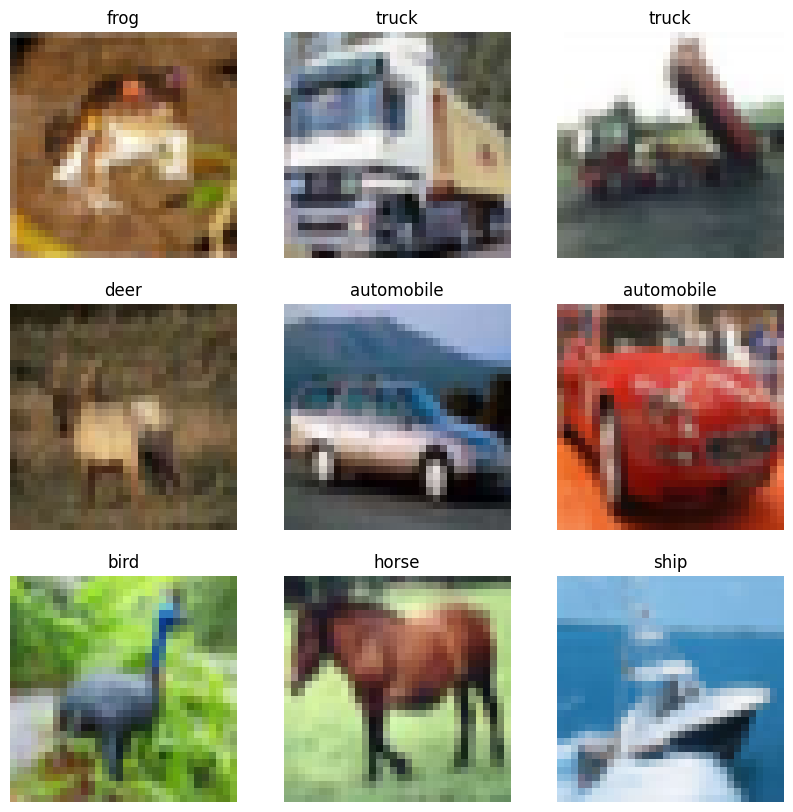

In [23]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

In [24]:
# Step 4: Build the CNN Model
model = models.Sequential([
#Task 1: Model Architecture Enhancement
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    
    
    layers.Conv2D(128, (3, 3), activation='relu',padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    
    layers.Flatten(),
    layers.Dense(288, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    
    layers.Dense(10, activation='softmax')

])
# Display model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 288)                 │       2,359,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 288)                 │           1,152 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           2,890 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,466,250 (9.41 MB)

 Trainable params: 2,465,610 (9.41 MB)

 Non-trainable params: 640 (2.50 KB)

In [25]:
#Task 2: Hyperparameter Optimization
from tensorflow.keras.optimizers import Adam
model.compile(Adam(learning_rate=0.0008),#學習率0.0008
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
from tensorflow.keras import callbacks

#加入EarlyStopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

from tensorflow.keras.callbacks import ReduceLROnPlateau

#加入lr_scheduler
lr_scheduler = ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
        )

In [26]:
#Task 3: Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

train_datagen.fit(train_images)

train_generator = train_datagen.flow(train_images, train_labels, batch_size=64)


history = model.fit(train_generator, epochs=10,
                    validation_data=(test_images, test_labels),
                    callbacks=[lr_scheduler,early_stop])

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.3464 - loss: 1.8455 - val_accuracy: 0.5050 - val_loss: 1.4555 - learning_rate: 8.0000e-04
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5233 - loss: 1.3173 - val_accuracy: 0.4982 - val_loss: 1.4797 - learning_rate: 8.0000e-04
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5972 - loss: 1.1293 - val_accuracy: 0.6270 - val_loss: 1.0872 - learning_rate: 8.0000e-04
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.6433 - loss: 1.0045 - val_accuracy: 0.6638 - val_loss: 0.9684 - learning_rate: 8.0000e-04
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6668 - loss: 0.9405 - val_accuracy: 0.7065 - val_loss: 0.8397 - learning_rate: 8.0000e-04
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6846 - loss: 0.8923 - val_accuracy: 0.6783 - val_loss: 0.9762 - learning_rate: 8.0000e-04
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/ste

In [27]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 - 1s - 4ms/step - accuracy: 0.7578 - loss: 0.6932

Test accuracy: 0.7578


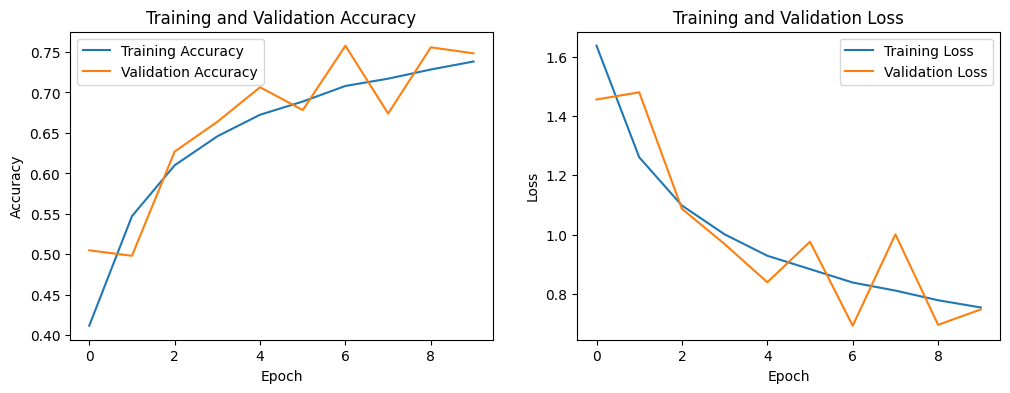

In [28]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [29]:
predictions = model.predict(test_images[:5])
for i in range(5):
    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[test_labels[i][0]]
    correct = "✅" if predicted_label == true_label else "❌"
    print(f"Image {i+1}: Predicted: {predicted_label}, True: {true_label}{correct}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Image 1: Predicted: cat, True: cat✅
Image 2: Predicted: ship, True: ship✅
Image 3: Predicted: ship, True: ship✅
Image 4: Predicted: airplane, True: airplane✅
Image 5: Predicted: frog, True: frog✅


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


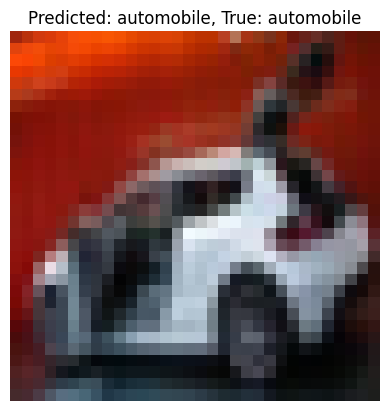

In [34]:
Task 4: Visualization
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

index = 6  
plt.imshow(test_images[index])
plt.title(f"Predicted: {class_names[predicted_labels[index]]}, True: {class_names[test_labels[index][0]]}")
plt.axis('off')
plt.show()

In [30]:
try:
    # Get final training accuracy
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    # Create performance summary
    performance_text = f"""Model Performance Summary:
Test Accuracy: {test_acc:.4f}
Test Loss: {test_loss:.4f}
Final Training Accuracy: {final_train_acc:.4f}
Final Validation Accuracy: {final_val_acc:.4f}
Final Training Loss: {final_train_loss:.4f}
Final Validation Loss: {final_val_loss:.4f}
Training Epochs: {len(history.history['accuracy'])}
Model Parameters: {model.count_params()}"""

    # Save to file for GitHub Actions
    with open('model_accuracy.txt', 'w') as f:
        f.write(performance_text)

    print("Model performance saved to model_accuracy.txt")
    print(performance_text)

except Exception as e:
    print(f"Error saving model performance: {e}")
    # Create a basic file even if there's an error
    with open('model_accuracy.txt', 'w') as f:
        f.write(f"Model execution completed with errors: {e}")

Model performance saved to model_accuracy.txt
Model Performance Summary:
Test Accuracy: 0.7578
Test Loss: 0.6932
Final Training Accuracy: 0.7383
Final Validation Accuracy: 0.7484
Final Training Loss: 0.7547
Final Validation Loss: 0.7482
Training Epochs: 10
Model Parameters: 2466250


In [37]:
#Task 5:Report
#本次實驗共加入了4層Conv2D，增大 Dense 層的單元數至 288，所有卷積層皆使用 padding='same'，確保特徵圖大小一致，加入一些Dropout防止overfitting
#使用 Adam 優化器，手動設定學習率為0.0008，加入 EarlyStopping，自動偵測是否過早過擬合，再加入動態學習率調整
#在資料增強部分，只水平和垂直平移最多±20%，並隨機水平翻轉影像，這個部份多次實驗發現將數字這定過大反而會將低準確度(正確來說是完全卡住)
#添加了可視化功能，顯示圖片，並將預測與真實類別一併顯示